# Demonstration of Loading and Visualising the Digital Earth Normalised Radar Backscatter Product for Sentinel-1 (Collection 1)

This notebook demonstrates key steps for using Python to load sample data from the Digital Earth Normalised Radar Backscatter Product for Sentinel-1 developed by Geoscience Australia. 
The notebook covers how to load via a STAC API or the Digital Earth Australia Datacube.

More detailed loading examples for each approach can be found in [03_loading_with_stac](03_loading_with_stac.ipynb) and [04_loading_with_datacube](04_loading_with_datacube.ipynb).

## Set-up

For this notebook, you will choose upfront if you want to run the STAC approach, or the Datacube approach.
Uncomment the approach you wish to run, leaving the other approach commented.

In [1]:
approach = "stac"
# approach = "datacube"

Then choose if you want to run an Australian or Antarctic example.
Uncomment the region you wish to run, leaving the other region commented.

In [2]:
# region = "Australia"
region = "Antarctica"

### Import required libraries

This imports python libraries that are used in both approaches, as well as any that are specific to the chosen approach. If using STAC on DEA Sandbox, you need to make sure you are using version 1.12.1 (or newer) of pystac, so we also check that the right version is being used

In [3]:
if approach == "stac":
    !pip install pystac==1.12.1

  Using cached pystac-1.12.1-py3-none-any.whl.metadata (4.6 kB)
Using cached pystac-1.12.1-py3-none-any.whl (194 kB)
  Attempting uninstall: pystac
    Found existing installation: pystac 1.11.0
    Uninstalling pystac-1.11.0:
      Successfully uninstalled pystac-1.11.0


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from odc.geo import BoundingBox
import odc.geo.xr
import pathlib
import xarray as xr

if approach == "stac":
    from pystac_client import Client
    from odc.stac import load, configure_s3_access

if approach == "datacube": 
    import datacube

### Environment set up

In [5]:
if approach == "stac":
    catalog = "https://explorer.dev.dea.ga.gov.au/stac"
    stac_client = Client.open(catalog)
    configure_s3_access(cloud_defaults=True, aws_unsigned=True)

if approach == "datacube": 
    dc = datacube.Datacube(env="dev", app="S1_Backscatter_Demo")

## Searching and Loading

For this demo, we have chosen Lake Sorell in Tasmania as the area of interest for Australia, and part of the Mertz Glacier as the area of interest for Antarctica.

We will perform a basic search and load.
To learn more about how to customise loading, check the following notebooks:
* [03_loading_with_stac](03_loading_with_stac.ipynb)
* [04_loading_with_datacube](04_loading_with_datacube.ipynb)

### Set up area of interest and date range

In [6]:
if region == "Australia":
    aoi_bbox = BoundingBox(
        left=147.09559,
        bottom=-42.14611,
        right=147.24500,
        top=-42.05599,
        crs="EPSG:4326"
    )

if region == "Antarctica":
    aoi_bbox = BoundingBox(
        left=77.849,
        bottom=-68.84,
        right=77.94,
        top=-68.9,
        crs="EPSG:4326"
    )

start_date = "2024-06-01"
end_date = "2024-07-01"

aoi_bbox.explore()

### Set up general data loading settings

* `product_to_load`: the product, or list of products to load from.
* `measurements_to_load`: the measurements to load from the data (e.g. VV_gamma0). If not specified, all measurements will be loaded.
* `output_crs`: the coordinate reference system (CRS) to project loaded data to. If not specified, the data's native CRS will be used.
* `output_res`: the resolution to load the data at, in the same units as the chosen CRS. If not specified, the data's native resolution will be used.
* `group_by_method`: how to group loaded data. Solar day is a sensible default.

We use different `product_to_load`, `measurement_to_load` and `output_crs` values for Australia and Antarctica, using the primary product for each region, as well as appropriate coordinate reference system.

In [7]:
if region == "Australia":
    # Load the VV+VH product
    product_to_load = "ga_s1_nrb_iw_vv_vh_1"
    measurements_to_load = ["vv_gamma0", "vh_gamma0", "oa_layover_shadow_mask"]
    output_crs = "EPSG:3577"

if region == "Antarctica":
    # Load the HH product
    product_to_load = "ga_s1_nrb_iw_hh_1"
    measurements_to_load = ["hh_gamma0", "oa_layover_shadow_mask"]
    output_crs = "EPSG:3031"

output_res = 20 # metres
group_by_method = "solar_day"

### Run search and load

There is a slight difference between STAC and the Open Data Cube, in that with STAC, the finding and loading steps are treated separately, whereas for the Open Data Cube, they can happen within a single call.

Data will be lazy-loaded, meaning a summary of the data to be loaded will be provided, but nothing will be loaded into memory. This is achieved with an argument for each load command:
* for odc.stac.load, this is done with the `chunks` argument.
* for dc.load, this is done with the `dask_chunks` argument.

In [8]:
if approach == "stac":

    stac_items = stac_client.search(
        collections=[product_to_load],
        datetime=f"{start_date}/{end_date}",
        bbox=aoi_bbox.bbox,
    ).item_collection()

    print(f"Found {len(stac_items)} items")

    ds = load(
        items=stac_items,
        bands=measurements_to_load,
        intersects=aoi_bbox.boundary(),
        crs=output_crs,
        resolution=output_res,
        groupby=group_by_method,
        chunks={},
    )

if approach == "datacube":
    ds = dc.load(
        product=product_to_load,
        measurements=measurements_to_load,
        lat=(aoi_bbox.bottom, aoi_bbox.top),
        lon=(aoi_bbox.left, aoi_bbox.right),
        output_crs=output_crs,
        resolution=(output_res, -output_res),
        time=(start_date, end_date),
        group_by=group_by_method,
        dask_chunks={}
    )

ds

Found 18 items


<xarray.Dataset> Size: 1GB
Dimensions:                 (y: 7079, x: 7717, time: 3)
Coordinates:
  * y                       (y) float64 57kB 5.642e+05 5.642e+05 ... 4.226e+05
  * x                       (x) float64 62kB 2.189e+06 2.189e+06 ... 2.343e+06
    spatial_ref             int32 4B 3031
  * time                    (time) datetime64[ns] 24B 2024-06-02T22:27:31.339...
Data variables:
    hh_gamma0               (time, y, x) float32 656MB dask.array<chunksize=(1, 7079, 7717), meta=np.ndarray>
    oa_layover_shadow_mask  (time, y, x) float32 656MB dask.array<chunksize=(1, 7079, 7717), meta=np.ndarray>

### Loading data in memory

Once you have decided you are happy with the area of interest, crs, resolution, bands, etc., you can load data into memory using xarray's `.compute` operation. 

This is valuable once you are ready to apply transformations to the data, or wish to visualise the data, as it will save needing to read the data into memory every time.

In [9]:
ds = ds.compute()

## Visualising and post-processing loaded data

The Digital Earth Normalised Radar Backscatter product for Sentinel-1 is provided as linear gamma0 values. 
It is common to apply some post-processing operations, such as masking, speckle filtering, and converting from linear scale to decibels.

To learn more about post-processing for this product, check the [05_post_processing](05_post_processing.ipynb) notebook.

#### Selecting the measurement for visualisation

For ease of use, we'll assign the primary co-polarisation measurement (VV for Australia, HH for Antarctica) to a new band to use throughout this section.

In [10]:
if region == "Australia":
    copol_measurement = "vv_gamma0"
if region == "Antarctica":
    copol_measurement = "hh_gamma0"

### Timeseries plot
To see the full timeseries for a particular band, the following plotting command can be used:

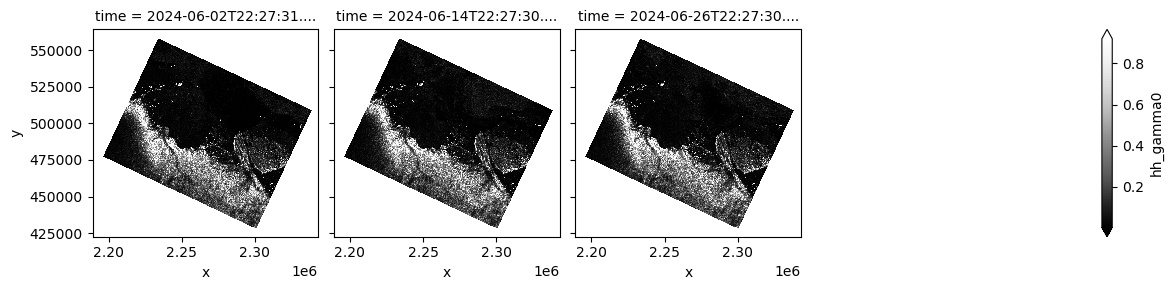

In [11]:
ds[copol_measurement].plot.imshow(col="time", col_wrap=4, robust=True, cmap="Greys_r")

### Masking

The Digital Earth Normalised Radar Backscatter product for Sentinel-1 comes with a mask that indicates invalid pixels, along with pixels impacted by layover and shadow. 

The masks have the following values:
| Value | Property |
| --- | ----------- |
| 0 | Valid | 
| 1 | Shadow |
| 2 | Layover |
| 3 | Shadow and layover |
| 255 / NaN | Invalid |

The following code displays the masks and shows how to apply them.
For the two regions in this notebook, there is minimal terrain, meaning there is very little (or no) areas impacted by layover or shadow.
For a clearer example, see the [05_post_processing](05_post_processing.ipynb) notebook.

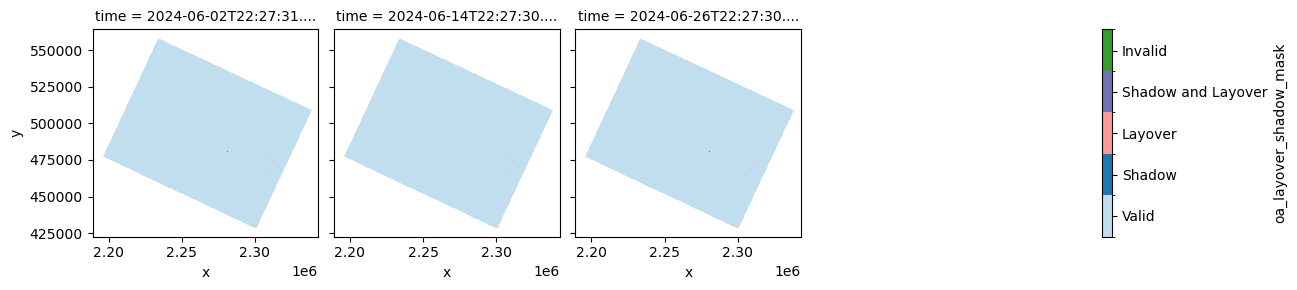

In [12]:
# Set up custom code to visualise the masks
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

cmap = mcolors.ListedColormap(["#c1deee", "#1f78b4", "#fb9a99", "#7570b3", "#33a02c"])
class_values = [0, 1, 2, 3, 255]
class_bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 255.5]
class_ticks = [0, 1, 2, 3, 126]
class_labels = ["Valid", "Shadow", "Layover", "Shadow and Layover", "Invalid"]
labels_dict = dict(zip(class_ticks, class_labels))

# Display masked
ds["oa_layover_shadow_mask"].plot.imshow(
    col="time", 
    col_wrap=4, 
    cmap=cmap,
    norm=mcolors.BoundaryNorm(class_bounds, cmap.N),
    cbar_kwargs={
        'ticks': class_ticks,
        'format': FuncFormatter(lambda v, _: labels_dict.get(int(v), ''))
    }
)

#### Dilating the mask

You may find that the shadow and layover mask will miss ridge lines in areas with steep terrain.
These often appear as overly bright ridges next to very dark areas.
This can happen as part of the geocoding process if the digital elevation model does not perfectly reflect the true terrain.
As such, we recommend dilating the layover shadow mask to ensure it encompasses ridges and other terrain features.

We have supplied a utility function for doing a simple dilation of a binary mask, where values of 1 should be dilated.
As such, we first select non-valid pixels to pass to the `dilate_mask` utility function.
This function has an argument for the disk radius (as a number of pixels) to use for the dilation footprint.
By default, this is set to a value of 3 pixels, but you may need to experiment with this to achieve the best masking for your data.

If you have any errors with importing `dilate_mask` make sure you have installed `de_sar_demo` as listed in the `README.md` in `de-sar-sample-data`. 

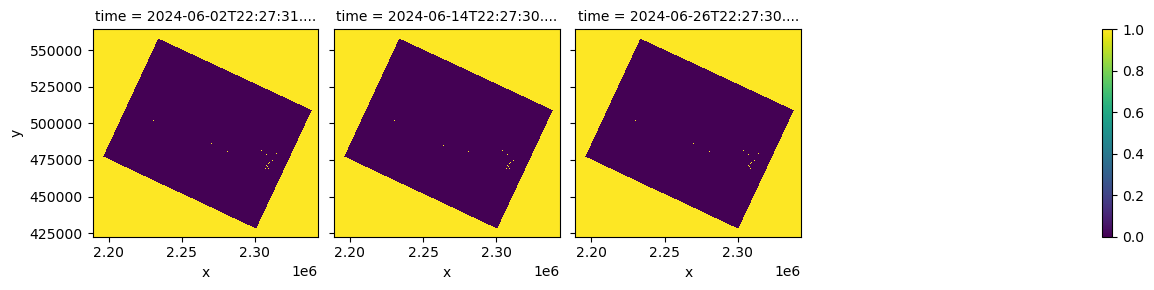

In [13]:
from de_sar_demo.masking import dilate_mask

# Create a layer with all non-valid pixels, including both layover and shadow
non_valid_pixels = ds["oa_layover_shadow_mask"] != 0

# Create the dilated mask
dilated_mask = dilate_mask(non_valid_pixels, dilation_radius=3)

dilated_mask.plot.imshow(col="time", col_wrap=4)

#### Applying the mask

To apply the mask, we use xarray's where function, which takes the condition, followed by the values to keep if the condition is true, followed by the values to use if the condition is false. 
The following code creates a new band, `copol_masked`, that keeps the original `hh_gamma0` or `vv_gamma0` values where the mask is equal to 0, and replaces values with NaN otherwise.

We display the masked data using a `viridis` colour map, which reveals the locations where the mask has been applied more clearly.
For the two regions in this notebook, there is minimal terrain, meaning there is very little (or no) areas impacted by layover or shadow.
For a clearer example, see the [05_post_processing](05_post_processing.ipynb) notebook.

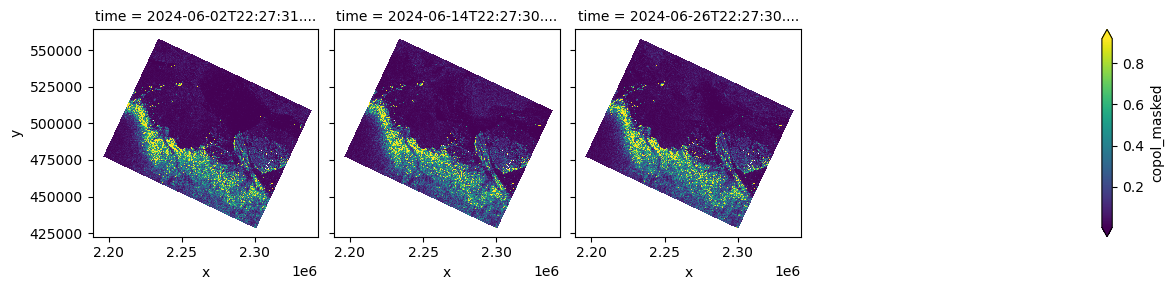

In [14]:
ds["copol_masked"] = xr.where(dilated_mask==0, ds[copol_measurement], np.nan)

ds["copol_masked"].plot.imshow(col="time", col_wrap=4, cmap="viridis", robust=True)
plt.show()

### Speckle filtering

Speckle filtering aims to reduce noise present in SAR images, and should be applied before converting to decibels. 
This is because the filter assumes a specific statistical distribution of the noise and converting to decibels changes the distribution of the noise.

One filter that is commonly applied is the Lee filter.
We have supplied a Python module `de_sar_demo` that contains the Lee filter definition, as well as a function to apply it to xarrays.
In this example, we apply the Lee filter using a uniform filter window size of 5 pixels.


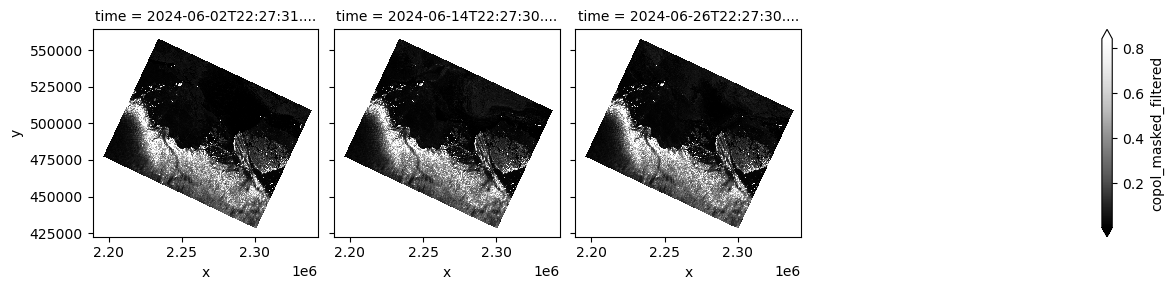

In [15]:
from de_sar_demo.speckle_filters import apply_lee_filter

ds["copol_masked_filtered"] = apply_lee_filter(ds["copol_masked"], size=5)

ds["copol_masked_filtered"].plot.imshow(col="time", col_wrap=4, cmap="Greys_r", robust=True)
plt.show()


### Converting to decibels

The Digital Earth Normalised Radar Backscatter product for Sentinel-1 is provided as linear gamma0. 
For some analyses, it may be beneficial to convert the linear backscatter to decibels (dB).

The conversion equation is 
$${\gamma^0}_{\text{dB}} = 10 \times \log_{10}({\gamma^0}_\text{linear})$$

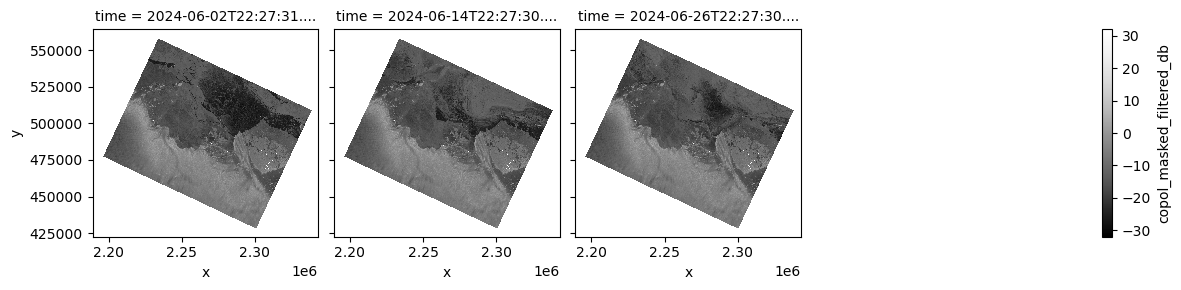

In [16]:
ds["copol_masked_filtered_db"] = 10*np.log10(ds["copol_masked_filtered"])

ds["copol_masked_filtered_db"].plot.imshow(col="time", col_wrap=4, cmap="Greys_r")
plt.show()


### Exporting

Once you have generated the data you need, you may wish to export it to enable further analysis.
The `odc-geo` python library provides a useful function for exporting cloud optimised GeoTIFFs.
First, we'll create a folder to store the outputs in.

In [17]:
output_path = pathlib.Path("outputs")
output_path.mkdir(exist_ok=True)

#### Exporting all time steps as Cloud Optimised GeoTIFFs

In [18]:
ds_datetime_strings = ds.time.dt.strftime("%Y-%m-%d").values

for timestep in range(len(ds.time)):
    filename = output_path / f"{region}_copol_filtered_masked_db_{ds_datetime_strings[timestep]}.tif"
    ds["copol_masked_filtered_db"].isel(time=timestep).odc.write_cog(filename, overwrite=True)